In [1]:
import sys
sys.path.insert(0, "src")

In [2]:
from predictr import Analysis, PlotAll
import numpy as np

In [3]:

# Weibull-Parameter
beta = 2.0    # Formparameter
eta = 100.0   # Skalenparameter (charakteristische Lebensdauer)
n = 20        # Stichprobenumfang

rng = np.random.default_rng(seed=42)
sample = eta * rng.weibull(beta, size=n)


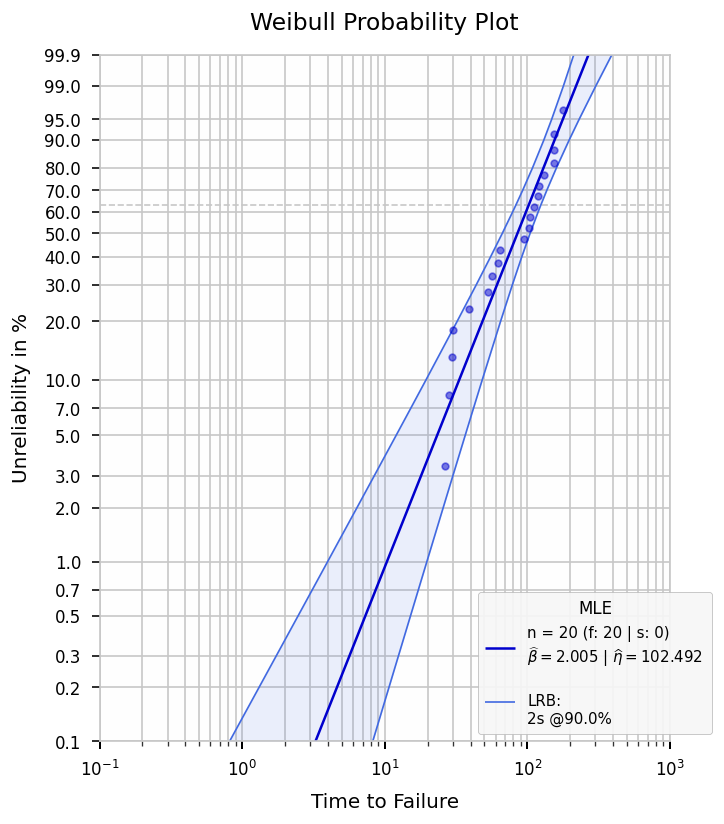

In [4]:
x = Analysis(df=sample, show=True, save=False, bounds='lrb')
x.mle()

In [5]:
import io
import json
import os
import ipywidgets as widgets
from IPython.display import display, Image

# --- Interaktives rcParams-Widget: Änderungen wirken sofort auf den Plot darunter ---
# Nutzt den vorhandenen 'sample' und baut bei jeder Änderung den Weibull-Plot
# (Analysis(...).mle()) neu auf. predictr.py wird dabei nicht verändert.

# WICHTIG:
# 1) predictr ruft intern bei jedem Plot plt.style.use(self.plot_style) auf
#    (Default 'predictr'). Das setzt figure.facecolor, axes.facecolor,
#    axes.edgecolor, grid.color etc. auf die Style-Defaults zurück und
#    überschreibt damit vorher gesetzte rcParams. Daher werden Figure-/
#    Achsen-/Grid-/Tick-/Titel-Abstand-Werte hier NICHT über rcParams
#    gesetzt, sondern nach dem Plotten direkt auf die bereits gezeichneten
#    Matplotlib-Objekte angewendet.
# 2) mle() baut den Plot nur auf, wenn show=True oder save=True ist
#    (predictr.py:604 "if self.show or self.save: self.plot()"). Mit
#    show=False würde also gar kein Plot gezeichnet. Lösung: mle() mit
#    show=False aufrufen (nur Berechnung), danach x_live.plot() explizit
#    selbst aufrufen, um die Figure zu erzeugen -> erst dann nachbearbeiten
#    und selbst anzeigen.
# 3) predictr positioniert die Legende fix mit
#    bbox_to_anchor=(0.65, 0.0) relativ zur Achse (predictr.py:1123). Bei
#    manchen bounds/bounds_type reicht sie über den rechten Achsen-/
#    Figurenrand hinaus. Statt dafür global bbox_inches='tight' zu
#    deaktivieren (das würde ALLE Plots im Notebook-Kernel betreffen, nicht
#    nur dieses Widget, und z.B. die Legende in ganz normalen predictr-
#    Zellen abschneiden - siehe genau dieses Problem, das wir zuvor damit
#    verursacht hatten), rendern wir hier selbst über einen PNG-Buffer mit
#    explizitem bbox_inches=None + vorheriger Breitenkorrektur (Punkt 4) -
#    das bleibt komplett lokal auf diese Zelle beschränkt und beeinflusst
#    keine anderen Zellen im Notebook mehr.
# 4) predictr koppelt Achsentitel (xlabel/ylabel) UND Tick-Zahlen an
#    denselben Parameter xy_fontsize (predictr.py:1063-1066). Damit beide
#    getrennt einstellbar sind, überschreiben wir nach dem Plotten
#    xlabel/ylabel-Fontsize separat von der Tick-Label-Fontsize
#    (ax.tick_params(labelsize=...)).
# 5) predictr zeichnet die Median-Gerade mit color='mediumblue' (predictr.py:1077)
#    und die Vertrauensbereiche mit color='royalblue' (z.B. predictr.py:1127),
#    standardmäßig mit unterschiedlicher Linienbreite (1.5 vs. 1.0). Wir
#    unterscheiden die Linien anhand dieser Farbe, um beide Breiten getrennt
#    einstellbar zu machen.

PRESETS_FILE = 'src/predictr_style_presets.json'

out = widgets.Output()

# --- Default-Werte (== predictr.mplstyle), für den Reset-Button ---
DEFAULTS = dict(
    fig_facecolor='#ffffff', axes_facecolor='#ffffff', axes_edgecolor='#cbcbcb',
    axes_edge_on=True, grid_color='#cbcbcb', legend_facecolor='#f0f0f0',
    legend_edgecolor='#cbcbcb', legend_frameon=True, xtick_pad=6, tick_size=5,
    linewidth_median=1.5, linewidth_bounds=1.0, title_fs=14, title_pad=10,
    axis_label_fs=11, tick_label_fs=11, legend_fs=10, legend_title_fs=11,
)


def load_presets():
    if os.path.exists(PRESETS_FILE):
        with open(PRESETS_FILE) as f:
            return json.load(f)
    return {}


def save_presets(presets):
    with open(PRESETS_FILE, 'w') as f:
        json.dump(presets, f, indent=4)


PRESETS = load_presets()
if '1st_draft' not in PRESETS:
    PRESETS['1st_draft'] = dict(DEFAULTS)
    save_presets(PRESETS)

# --- Widgets für die relevantesten rcParams (mit Tooltip-Erklärung) ---
w_fig_facecolor = widgets.ColorPicker(
    description='Figure BG', value=DEFAULTS['fig_facecolor'],
    tooltip='figure.set_facecolor(): Hintergrundfarbe der gesamten Figure (außerhalb der Plotfläche).')
w_axes_facecolor = widgets.ColorPicker(
    description='Plot BG', value=DEFAULTS['axes_facecolor'],
    tooltip='axes.set_facecolor(): Hintergrundfarbe der eigentlichen Plotfläche (innerhalb der Achsen).')
w_axes_edgecolor = widgets.ColorPicker(
    description='Achsenrahmen', value=DEFAULTS['axes_edgecolor'],
    tooltip='spine.set_color(): Farbe des Rahmens rund um die Plotfläche.')
w_axes_edge_on = widgets.Checkbox(
    description='Achsenrahmen an', value=DEFAULTS['axes_edge_on'],
    tooltip='spine.set_visible(): Ob der Rahmen rund um die Plotfläche überhaupt gezeichnet wird.')
w_grid_color = widgets.ColorPicker(
    description='Grid', value=DEFAULTS['grid_color'],
    tooltip='gridline.set_color(): Farbe der Gitternetzlinien im Plot.')
w_legend_facecolor = widgets.ColorPicker(
    description='Legende BG', value=DEFAULTS['legend_facecolor'],
    tooltip='legend.get_frame().set_facecolor(): Hintergrundfarbe der Legendenbox.')
w_legend_edgecolor = widgets.ColorPicker(
    description='Legende Rahmen', value=DEFAULTS['legend_edgecolor'],
    tooltip='legend.get_frame().set_edgecolor(): Farbe des Rahmens um die Legendenbox.')
w_legend_frameon = widgets.Checkbox(
    description='Legende Rahmen an', value=DEFAULTS['legend_frameon'],
    tooltip='legend.get_frame().set_visible(): Ob überhaupt ein Rahmen/Hintergrund um die Legende gezeichnet wird.')

w_xtick_pad = widgets.IntSlider(
    description='Tick Pad', min=0, max=20, value=DEFAULTS['xtick_pad'],
    tooltip='ax.tick_params(pad=...): Abstand zwischen Achse und Tick-Beschriftung (Zahlen).')
w_tick_size = widgets.IntSlider(
    description='Tick Länge', min=0, max=12, value=DEFAULTS['tick_size'],
    tooltip='ax.tick_params(length=...): Länge der Tick-Striche an der Achse.')
w_linewidth_median = widgets.FloatSlider(
    description='Linienbreite Median', min=0.5, max=6, step=0.5, value=DEFAULTS['linewidth_median'],
    tooltip='line.set_linewidth(): Dicke der Median-Gerade (MLE/MRR, color="mediumblue").')
w_linewidth_bounds = widgets.FloatSlider(
    description='Linienbreite Bounds', min=0.5, max=6, step=0.5, value=DEFAULTS['linewidth_bounds'],
    tooltip='line.set_linewidth(): Dicke der Vertrauensbereich-Linien (color="royalblue"). '
            'Standardmäßig wie bei predictr etwas schmaler als die Median-Gerade.')

w_title_fs = widgets.IntSlider(
    description='Titel FS', min=8, max=24, value=DEFAULTS['title_fs'],
    tooltip='Analysis(plot_title_fontsize=...): Schriftgröße des Plot-Titels.')
w_title_pad = widgets.IntSlider(
    description='Titel Abstand', min=0, max=40, value=DEFAULTS['title_pad'],
    tooltip='ax.set_title(pad=...): Abstand (in Punkten) zwischen Titel und Plotfläche.')
w_axis_label_fs = widgets.IntSlider(
    description='Achsen Label FS', min=6, max=20, value=DEFAULTS['axis_label_fs'],
    tooltip='ax.set_xlabel/set_ylabel(fontsize=...): Schriftgröße der Achsentitel (z.B. "Unreliability"), '
            'unabhängig von den Tick-Zahlen.')
w_tick_label_fs = widgets.IntSlider(
    description='Tick Zahlen FS', min=6, max=20, value=DEFAULTS['tick_label_fs'],
    tooltip='ax.tick_params(labelsize=...): Schriftgröße der Zahlen an den Achsen (z.B. "0.1", "10^-1"), '
            'unabhängig vom Achsentitel.')
w_legend_fs = widgets.IntSlider(
    description='Legende FS', min=6, max=20, value=DEFAULTS['legend_fs'],
    tooltip='Analysis(legend_fontsize=...): Schriftgröße der Legendeneinträge, z.B. "MLE"/"MRR".')
w_legend_title_fs = widgets.IntSlider(
    description='Legende Titel FS', min=6, max=24, value=DEFAULTS['legend_title_fs'],
    tooltip='legend.get_title().set_fontsize(): Schriftgröße des Legenden-Titels (z.B. "MLE").')

reset_btn = widgets.Button(description='Reset auf Default', icon='undo',
                            tooltip='Setzt alle Regler zurück auf die predictr.mplstyle-Werte.')

ALL_CONTROLS = dict(
    fig_facecolor=w_fig_facecolor, axes_facecolor=w_axes_facecolor,
    axes_edgecolor=w_axes_edgecolor, axes_edge_on=w_axes_edge_on,
    grid_color=w_grid_color, legend_facecolor=w_legend_facecolor,
    legend_edgecolor=w_legend_edgecolor, legend_frameon=w_legend_frameon,
    xtick_pad=w_xtick_pad, tick_size=w_tick_size,
    linewidth_median=w_linewidth_median, linewidth_bounds=w_linewidth_bounds,
    title_fs=w_title_fs, title_pad=w_title_pad, axis_label_fs=w_axis_label_fs,
    tick_label_fs=w_tick_label_fs, legend_fs=w_legend_fs,
    legend_title_fs=w_legend_title_fs,
)

# --- Presets: aktuelle Konfiguration unter einem Namen speichern/laden ---
w_preset_select = widgets.Dropdown(
    description='Preset', options=list(PRESETS.keys()), value='1st_draft',
    tooltip='Gespeicherte Konfigurationen auswählen und anklicken, um sie zu laden.')
w_preset_name = widgets.Text(
    description='Name', value='1st_draft', placeholder='z.B. 1st_draft',
    tooltip='Name, unter dem die aktuelle Reglereinstellung gespeichert wird.')
save_preset_btn = widgets.Button(description='Preset speichern', icon='save',
                                  tooltip='Speichert die aktuelle Konfiguration unter obigem Namen.')
load_preset_btn = widgets.Button(description='Preset laden', icon='folder-open',
                                  tooltip='Lädt die ausgewählte, gespeicherte Konfiguration.')

controls = widgets.VBox([
    widgets.HTML('<b>Presets</b>'),
    w_preset_select, load_preset_btn, w_preset_name, save_preset_btn,
    widgets.HTML('<b>Farben</b>'),
    w_fig_facecolor, w_axes_facecolor, w_axes_edgecolor, w_axes_edge_on, w_grid_color,
    w_legend_facecolor, w_legend_edgecolor, w_legend_frameon,
    widgets.HTML('<b>Ticks & Linien</b>'),
    w_xtick_pad, w_tick_size, w_linewidth_median, w_linewidth_bounds,
    widgets.HTML('<b>Schriftgrößen</b>'),
    w_title_fs, w_title_pad, w_axis_label_fs, w_tick_label_fs, w_legend_fs, w_legend_title_fs,
    reset_btn,
])


def render(*_):
    with out:
        out.clear_output(wait=True)

        plt.close('all')
        # show=False: mle() nur berechnen lassen (kein Auto-Plot), danach
        # plot() explizit selbst aufrufen -> Figure entsteht, wird aber noch
        # nicht angezeigt/geschlossen, sodass wir sie nachbearbeiten können.
        x_live = Analysis(df=sample, show=False, save=False, bounds='lrb',
                           plot_title_fontsize=w_title_fs.value,
                           xy_fontsize=w_axis_label_fs.value,
                           legend_fontsize=w_legend_fs.value)
        x_live.mle()
        x_live.plot()

        fig = plt.gcf()
        ax = plt.gca()

        fig.set_facecolor(w_fig_facecolor.value)
        ax.set_facecolor(w_axes_facecolor.value)
        for spine in ax.spines.values():
            spine.set_visible(w_axes_edge_on.value)
            spine.set_color(w_axes_edgecolor.value)
        for gl in ax.get_xgridlines() + ax.get_ygridlines():
            gl.set_color(w_grid_color.value)
        ax.tick_params(axis='both', which='major', pad=w_xtick_pad.value,
                        length=w_tick_size.value, labelsize=w_tick_label_fs.value)
        for line in ax.get_lines():
            # Median-Gerade (MLE/MRR) vs. Vertrauensbereich-Linien anhand
            # der von predictr fest vergebenen Farbe unterscheiden.
            if line.get_color() == 'mediumblue':
                line.set_linewidth(w_linewidth_median.value)
            elif line.get_color() == 'royalblue':
                line.set_linewidth(w_linewidth_bounds.value)
            else:
                line.set_linewidth(w_linewidth_median.value)
        ax.set_title(ax.get_title(), pad=w_title_pad.value,
                     fontsize=w_title_fs.value, color='black')
        ax.set_xlabel(ax.get_xlabel(), fontsize=w_axis_label_fs.value, color='black')
        ax.set_ylabel(ax.get_ylabel(), fontsize=w_axis_label_fs.value, color='black')

        legend = ax.get_legend()
        if legend is not None:
            frame = legend.get_frame()
            frame.set_facecolor(w_legend_facecolor.value)
            frame.set_edgecolor(w_legend_edgecolor.value)
            frame.set_visible(w_legend_frameon.value)
            legend.get_title().set_fontsize(w_legend_title_fs.value)

            # predictr verankert die Legende bei bbox_to_anchor=(0.65, 0.0)
            # relativ zur Achse (predictr.py:1123) -> kann über den rechten
            # Figurenrand hinausragen. Figure ggf. verbreitern, statt die
            # Legende abzuschneiden.
            fig.canvas.draw()
            legend_bbox = legend.get_window_extent()
            fig_bbox = fig.get_window_extent()
            if legend_bbox.x1 > fig_bbox.x1:
                extra_in = (legend_bbox.x1 - fig_bbox.x1) / fig.dpi
                w_in, h_in = fig.get_size_inches()
                fig.set_size_inches(w_in + extra_in + 0.15, h_in)

        # Lokal (nur für dieses Widget) mit bbox_inches=None rendern, damit
        # die Figure-Hintergrundfarbe sichtbar bleibt, OHNE die globale
        # IPython-Inline-Konfiguration zu ändern (das würde sonst alle
        # anderen Zellen im Notebook mit-beeinflussen, s. Kommentar oben).
        buf = io.BytesIO()
        fig.savefig(buf, format='png', facecolor=fig.get_facecolor(), bbox_inches=None)
        buf.seek(0)
        display(Image(data=buf.getvalue()))
        plt.close(fig)


def reset(*_):
    for key, ctrl in ALL_CONTROLS.items():
        ctrl.value = DEFAULTS[key]
    render()


def apply_config(cfg):
    for key, ctrl in ALL_CONTROLS.items():
        if key in cfg:
            ctrl.value = cfg[key]
    render()


def save_preset(*_):
    name = w_preset_name.value.strip()
    if not name:
        return
    PRESETS[name] = {key: ctrl.value for key, ctrl in ALL_CONTROLS.items()}
    save_presets(PRESETS)
    if name not in w_preset_select.options:
        w_preset_select.options = list(PRESETS.keys())
    w_preset_select.value = name


def load_preset(*_):
    name = w_preset_select.value
    if name in PRESETS:
        apply_config(PRESETS[name])


for w in ALL_CONTROLS.values():
    w.observe(render, names='value')

reset_btn.on_click(reset)
save_preset_btn.on_click(save_preset)
load_preset_btn.on_click(load_preset)

display(widgets.HBox([controls, out]))
render()

# Beispiele aus der predictr-Dokumentation
Quelle: https://tvtoglu.github.io/predictr/classes/

## Maximum Likelihood Estimation (MLE)
### Uncensored sample

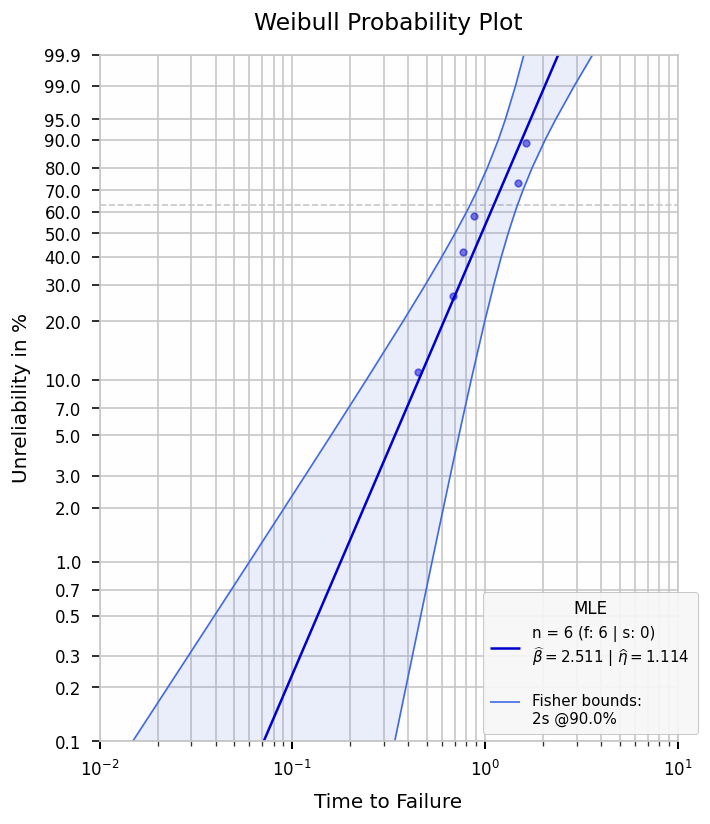

In [6]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
prototype_a = Analysis(df=failures, bounds='fb',show=True)
prototype_a.mle()

### Censored sample

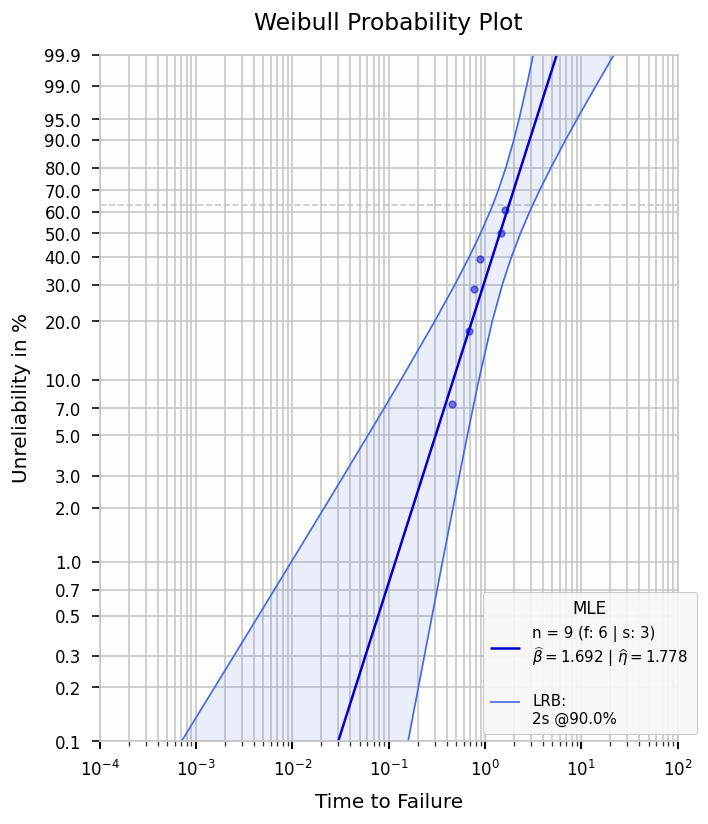

In [7]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
suspensions = [1.9, 2.0, 2.0]
prototype_a = Analysis(df=failures, ds=suspensions, bounds='lrb',show=True)
prototype_a.mle()

## Median Rank Regression (MRR)
### Parameter estimation methods

### Uncensored sample

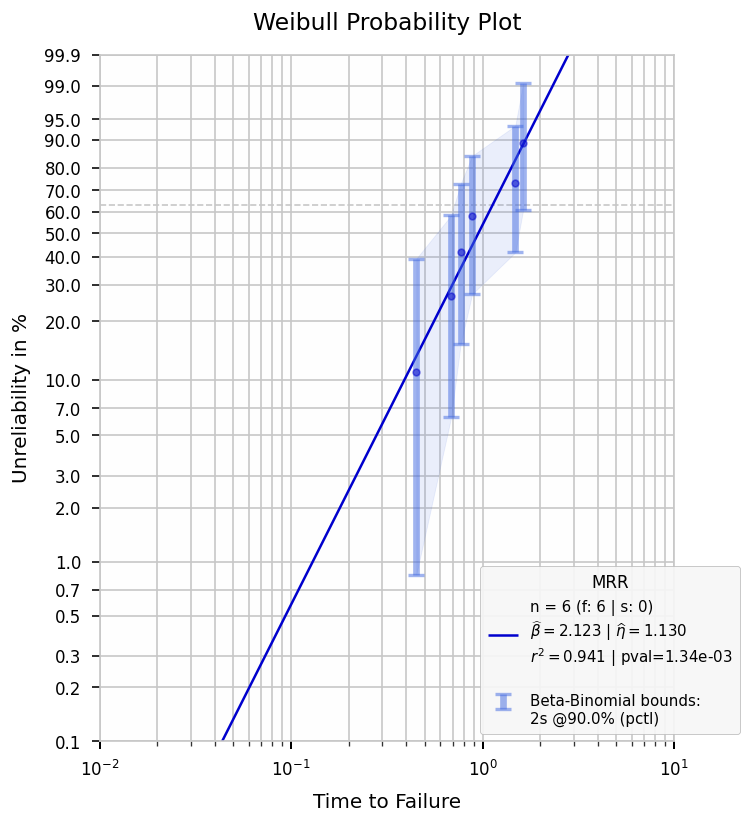

In [8]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
prototype_a = Analysis(df=failures, bounds='bbb',show=True)
prototype_a.mrr()

### Censored sample

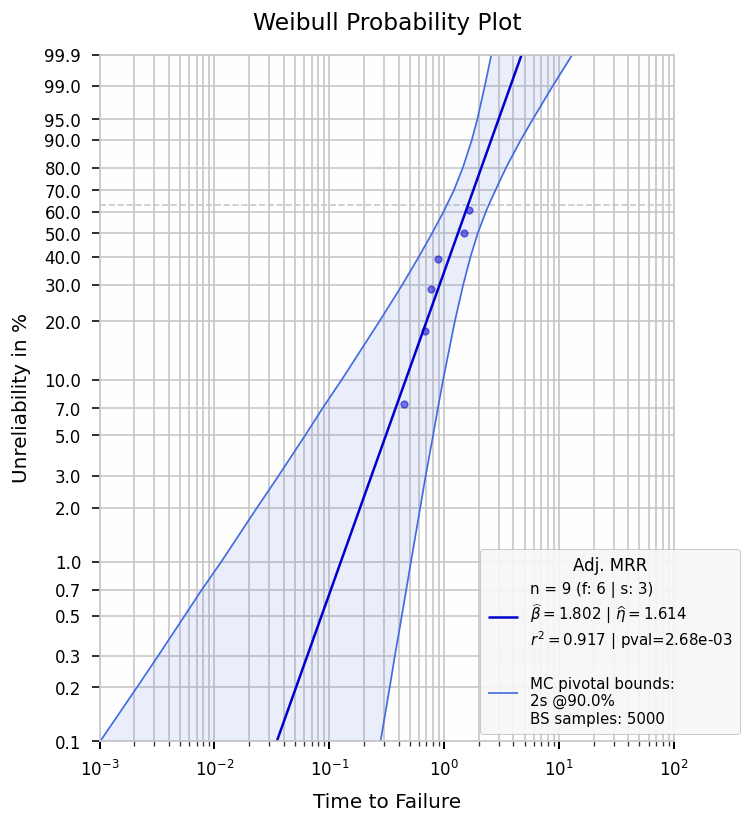

In [9]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
suspensions = [1.9, 2.0, 2.0]
prototype_a = Analysis(df=failures, ds=suspensions, bounds='mcpb',show=True)
prototype_a.mrr()

## Bias-corrections
### Uncensored sample

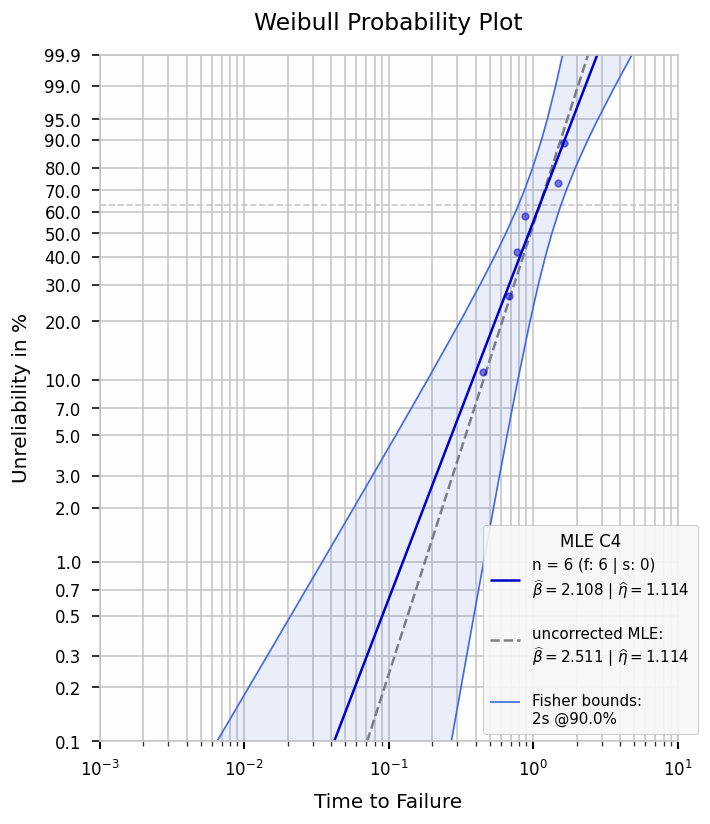

In [10]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
prototype_a = Analysis(df=failures, bounds='fb', show=True, bcm='c4')
prototype_a.mle()

In [11]:
print(f'biased beta: {prototype_a.beta:4f} --> bias-corrected beta: {prototype_a.beta_c4:4f}')

biased beta: 2.511134 --> bias-corrected beta: 2.108248


### Censored sample

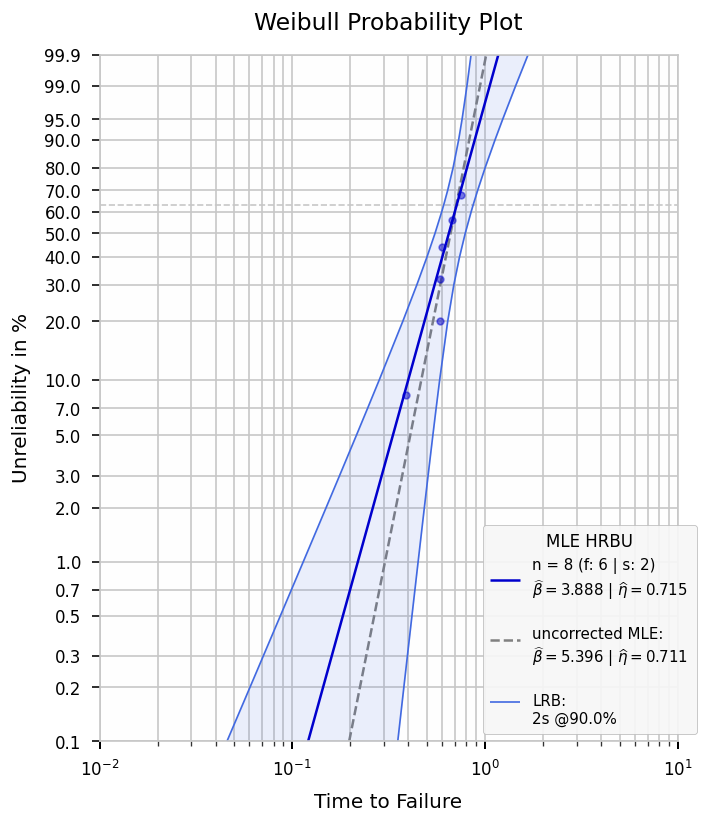

In [12]:
failures = [0.38760099164906514, 0.5867052007217437, 0.5878056753744406, 0.602290402929083, 0.6754829518358306, 0.7520219855697948]
suspensions = [0.7520219855697948, 0.7520219855697948]
prototype_a = Analysis(df=failures, ds=suspensions, bounds='lrb', show=True, bcm='hrbu')
prototype_a.mle()

## Modifying the Weibull plot
### Axes labels and title

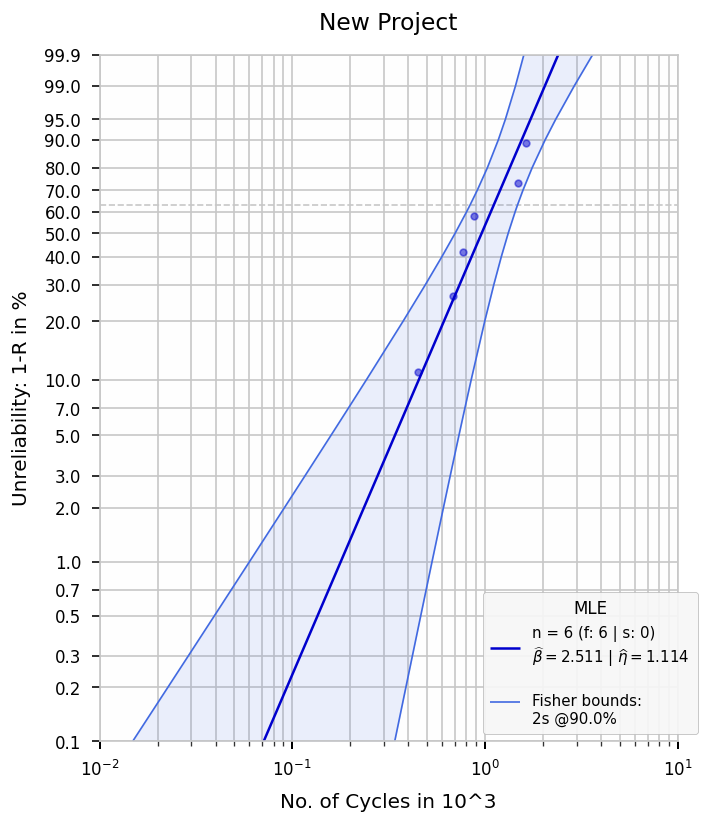

In [13]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
prototype_a = Analysis(df=failures, bounds='fb',show=True, plot_title='New Project', x_label='No. of Cycles', unit='10^3', y_label='Unreliability: 1-R', xy_fontsize=12)
prototype_a.mle()

### Figure size, plot legend and median rank markers

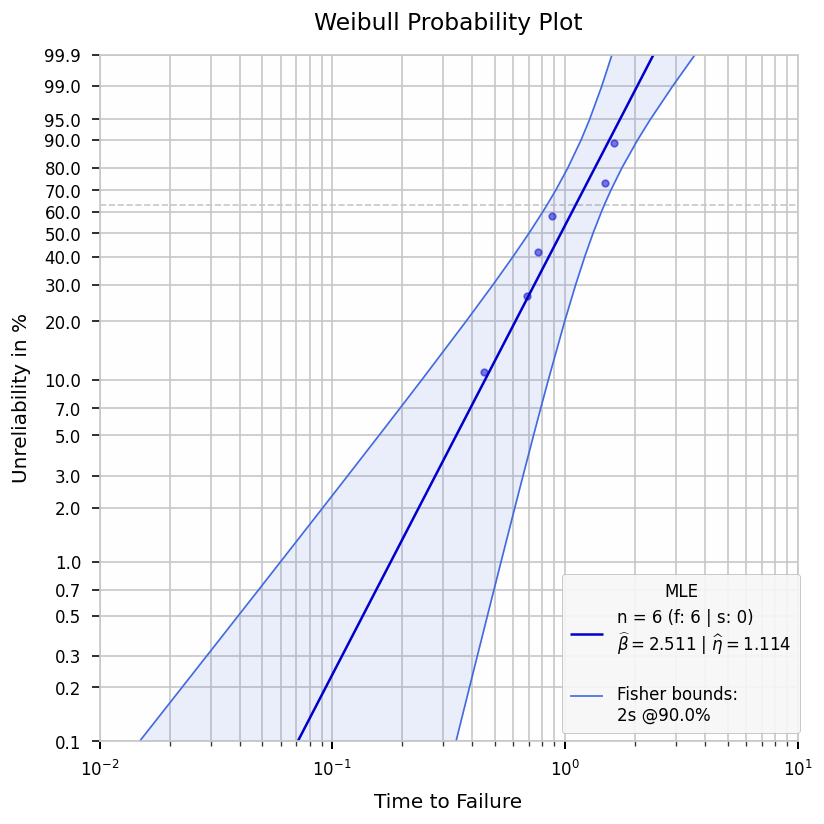

In [14]:
failures = [0.4508831,  0.68564703, 0.76826143, 0.88231395, 1.48287253, 1.62876357]
prototype_a = Analysis(df=failures, bounds='fb',show=True, show_legend=True, legend_fontsize=10, show_ranks=False, fig_size=(7, 7))
prototype_a.mle()

## mult_weibull()
### Both with two-sided bounds - default colors

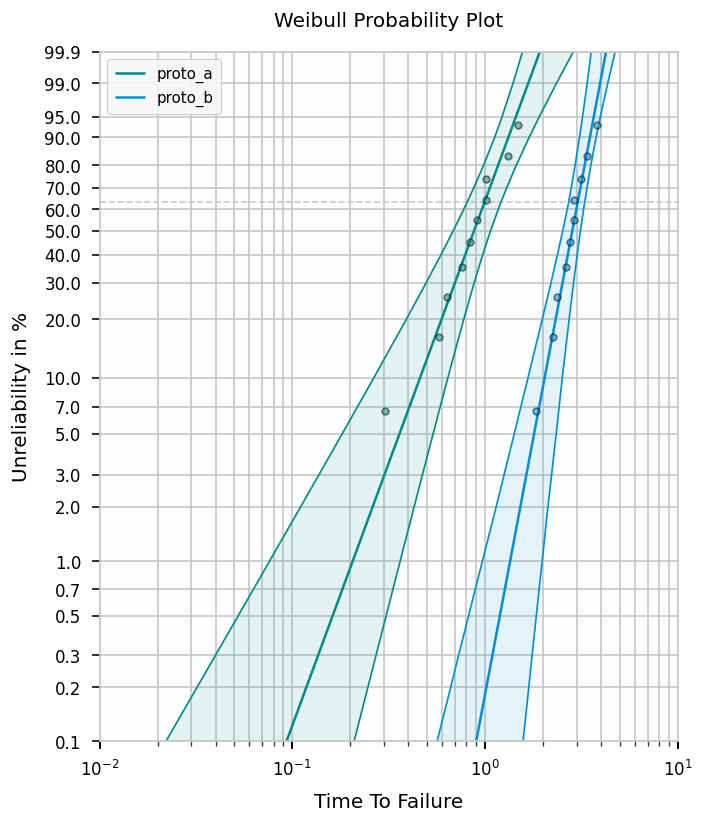

In [15]:
from predictr import Analysis, PlotAll

failures_a = [0.30481336314657737, 0.5793918872111126, 0.633217732127894, 0.7576700925659532,
              0.8394342818048925, 0.9118100898948334, 1.0110147142055477, 1.0180126386295232,
              1.3201853093496474, 1.492172669340363]
prototype_a = Analysis(df=failures_a, bounds='lrb', bounds_type='2s')
prototype_a.mle()

failures_b = [1.8506941739639076, 2.2685555679846954, 2.380993183650987, 2.642404955035375,
              2.777082863078587, 2.89527127055147, 2.9099992138728927, 3.1425481097241,
              3.3758727398694406, 3.8274990886889997]
prototype_b = Analysis(df=failures_b, bounds='pbb', bounds_type='2s')
prototype_b.mle()

objects = {'proto_a': prototype_a, 'proto_b': prototype_b}

PlotAll(objects).mult_weibull()

### One object with a one-sided lower bound, the other one has two-sided bounds

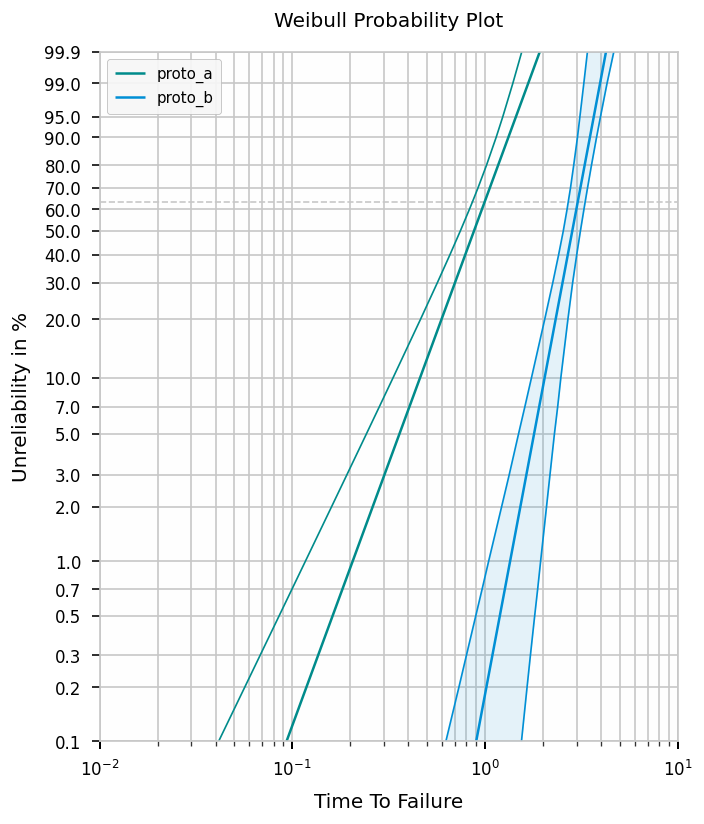

In [16]:
from predictr import Analysis, PlotAll

failures_a = [0.30481336314657737, 0.5793918872111126, 0.633217732127894, 0.7576700925659532,
              0.8394342818048925, 0.9118100898948334, 1.0110147142055477, 1.0180126386295232,
              1.3201853093496474, 1.492172669340363]
prototype_a = Analysis(df=failures_a, bounds='fb', bounds_type='1sl')
prototype_a.mle()

failures_b = [1.8506941739639076, 2.2685555679846954, 2.380993183650987, 2.642404955035375,
              2.777082863078587, 2.89527127055147, 2.9099992138728927, 3.1425481097241,
              3.3758727398694406, 3.8274990886889997]
prototype_b = Analysis(df=failures_b, bounds='npbb', bounds_type='2s')
prototype_b.mle()

objects = {'proto_a': prototype_a, 'proto_b': prototype_b}

PlotAll(objects).mult_weibull(plot_ranks=False)

### Three objects - custom colors

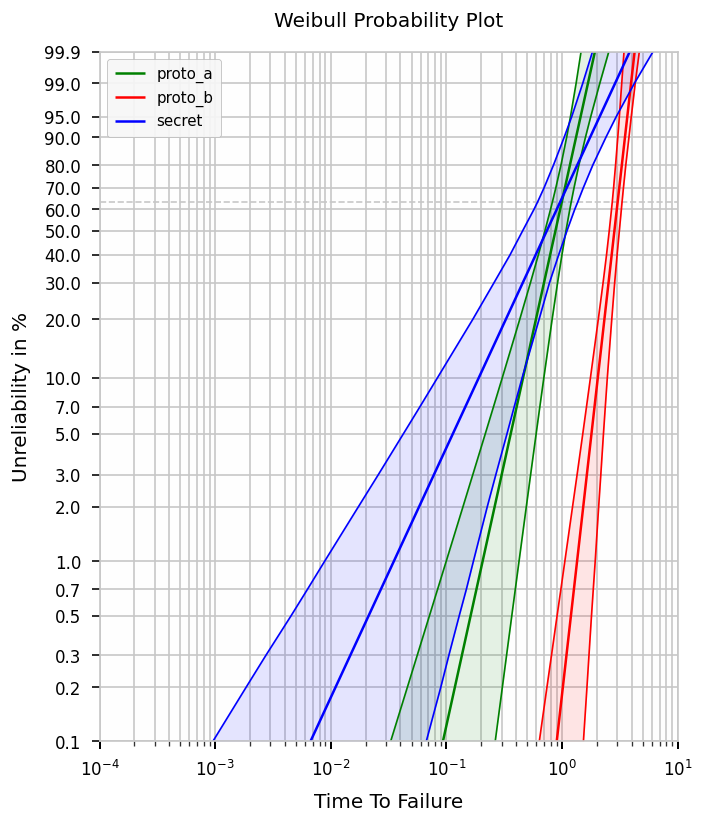

In [17]:
failures_a = [0.30481336314657737, 0.5793918872111126, 0.633217732127894, 0.7576700925659532,
              0.8394342818048925, 0.9118100898948334, 1.0110147142055477, 1.0180126386295232,
              1.3201853093496474, 1.492172669340363]
prototype_a = Analysis(df=failures_a, bounds='fb', bounds_type='2s')
prototype_a.mle()

failures_b = [1.8506941739639076, 2.2685555679846954, 2.380993183650987, 2.642404955035375,
              2.777082863078587, 2.89527127055147, 2.9099992138728927, 3.1425481097241,
              3.3758727398694406, 3.8274990886889997]
prototype_b = Analysis(df=failures_b, bounds='npbb', bounds_type='2s')
prototype_b.mle()

failures_c = [0.04675399107295282, 0.31260891592041457, 0.32121232576015757, 0.6013488316204837,
              0.7755159796641791, 0.8994041575114923, 0.956417788622185, 1.1967354178170764,
              1.6115311492838604, 2.1120891587523793]
prototype_c = Analysis(df=failures_c, bounds='pbb', bounds_type='2s')
prototype_c.mle()

objects = {'proto_a': prototype_a, 'proto_b': prototype_b, 'secret': prototype_c}
colors = ['green', 'red', 'blue']
PlotAll(objects).mult_weibull(plot_ranks=False, color=colors)

## contour_plot()
### Plot a single Analysis object

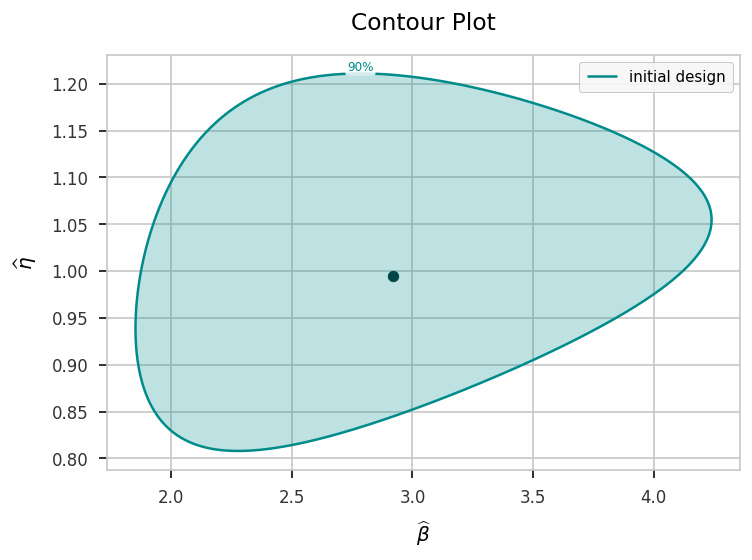

In [18]:
from predictr import Analysis, PlotAll

failures_a = [0.30481336314657737, 0.5793918872111126, 0.633217732127894, 0.7576700925659532,
              0.8394342818048925, 0.9118100898948334, 1.0110147142055477, 1.0180126386295232,
              1.3201853093496474, 1.492172669340363]
prototype_a = Analysis(df=failures_a, bounds='lrb', bounds_type='2s')
prototype_a.mle()

objects = {'initial design': prototype_a}
PlotAll(objects).contour_plot()

### Plot a multiple Analysis objects

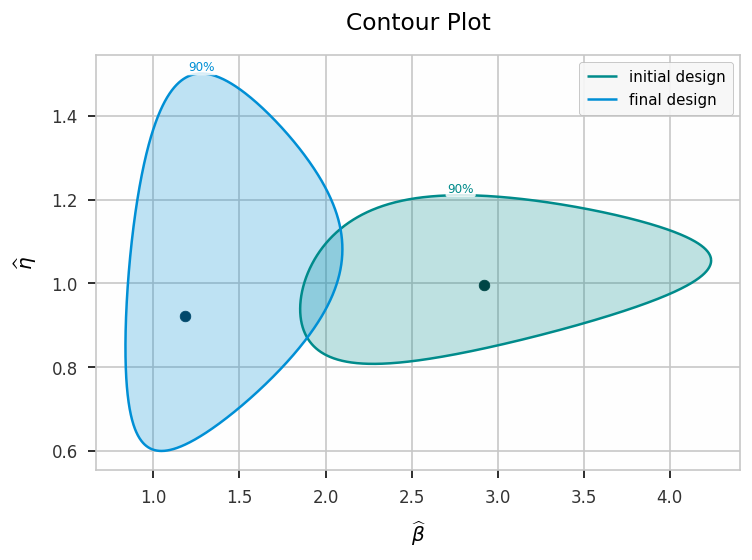

In [19]:
failures_a = [0.30481336314657737, 0.5793918872111126, 0.633217732127894, 0.7576700925659532,
              0.8394342818048925, 0.9118100898948334, 1.0110147142055477, 1.0180126386295232,
              1.3201853093496474, 1.492172669340363]
prototype_a = Analysis(df=failures_a, bounds='lrb', bounds_type='2s')
prototype_a.mle()

failures_c = [0.04675399107295282, 0.31260891592041457, 0.32121232576015757, 0.6013488316204837,
              0.7755159796641791, 0.8994041575114923, 0.956417788622185, 1.1967354178170764,
              1.6115311492838604, 2.1120891587523793]
prototype_c = Analysis(df=failures_c, bounds='lrb', bcm = 'hrbu', bounds_type='2s')
prototype_c.mle()

objects = {'initial design': prototype_a, 'final design': prototype_c}
PlotAll(objects).contour_plot()

## weibull_pdf()

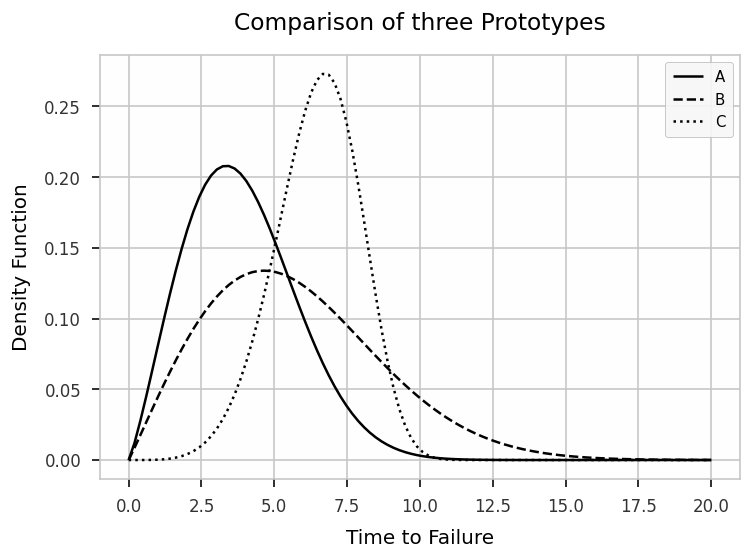

In [20]:
from predictr import Analysis, PlotAll

failures1 = [3, 3, 3, 3, 3, 3, 4, 4, 9]
failures2 = [3, 3, 5, 6, 6, 4, 9]
failures3 = [5, 6, 6, 6, 7, 9]

a = Analysis(df=failures1, bounds='lrb', bounds_type='2s', show = False, unit= 'min')
a.mle()

b = Analysis(df=failures1, ds = failures2, bounds='fb', bounds_type='2s', show = False, unit= 'min')
b.mle()

c = Analysis(df=failures3, bounds='lrb', bcm='hrbu', bounds_type='2s', show = False, unit= 'min')
c.mle()

PlotAll().weibull_pdf(beta = [a.beta, b.beta, c.beta], eta = [a.eta, b.eta, c.eta],
                      linestyle=['-', '--', ':'], labels = ['A', 'B', 'C'],
                x_bounds=[0, 20, 100], plot_title = 'Comparison of three Prototypes',
                x_label='Time to Failure', y_label='Density Function',
                 color=['black', 'black', 'black'])

## simple_weibull()

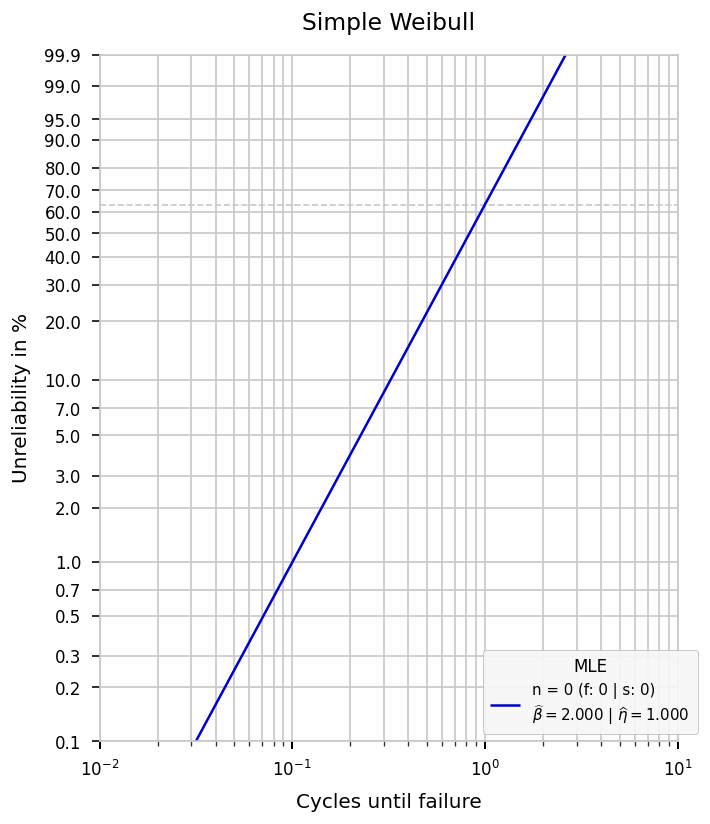

In [21]:
from predictr import Analysis, PlotAll

PlotAll().simple_weibull(beta =2.0, eta=1, show_legend=True, x_label='Cycles until failure', plot_title='Simple Weibull')